# Modeling: Emerging Technology Signal Detection
### CIS 2450—Final Project

We're predicting whether a topic will appear in an expert newsletter in the
next two weeks, using signal activity from research, developer, and community sources.

**What EDA told us:**
- `topic_nl_rate_8wk` (+0.22) and `topic_nl_rate_alltime` (+0.18) are the strongest
  predictors—editors are habitual
- `weeks_since_last_nl` (-0.18) captures freshness
- `burst_score` wasn't significant overall (p=0.54) but may matter for novel topics
- Class ratio 1:23—accuracy is meaningless, we use F1, ROC-AUC, Precision@K

**Three models, all from class:**
- Decision Tree: explainable baseline, tune max_depth to prevent overfitting
- Logistic Regression: sigmoid + gradient descent + L2 regularization
- Random Forest: ensemble of trees via bagging—our primary model

**Split: train / validation / test (all temporal—no shuffling)**
- Train: first 70% of weeks—used to fit models
- Validation: next 15%—used ONLY for hyperparameter tuning
- Test: final 15%—used once at the end for final evaluation

In [28]:
import os
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import polars as pl
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
from datetime import datetime, timedelta
from scipy import stats
import re
from functools import lru_cache

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.calibration import CalibrationDisplay
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    f1_score,
    roc_curve,
    confusion_matrix,
    average_precision_score,
)
from sklearn.utils.class_weight import compute_class_weight
import sklearn.metrics

plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

PROCESSED_DIR = "/Users/sarinafernandez-grinshpun/CIS2450FinalProject/data/processed"

SOURCE_TYPE_MAP = {
    "arxiv": "research",
    "semantic_scholar": "research",
    "github": "developer",
    "reddit": "discussion",
    "hackernews": "discussion",
}

## 1. Rebuild Feature Matrix

Same logic as EDA, rebuilt here so this notebook runs standalone.
All features are computed causally—no peeking past week t.

In [29]:
topics_df = pl.read_csv(os.path.join(PROCESSED_DIR, "canonical_topics.csv"))
nl_df = pl.read_csv(os.path.join(PROCESSED_DIR, "newsletter_topic_map.csv"))
sig_df = pl.read_csv(
    os.path.join(PROCESSED_DIR, "signal_topic_map.csv"),
    schema_overrides={
        "date": pl.Utf8,
        "week": pl.Utf8,
        "phrase": pl.Utf8,
        "source": pl.Utf8,
        "canonical_topic": pl.Utf8,
        "score": pl.Float64,
        "similarity": pl.Float64,
    }
)
sig_df = sig_df.with_columns(
    pl.col("source").replace_strict(SOURCE_TYPE_MAP, default="other").alias("source_type")
)

WEEK_PATTERN = re.compile(r'^\d{4}-W\d{2}$')

@lru_cache(maxsize=512)
def parse_week(w):
    try:
        return datetime.strptime(w + '-1', '%G-W%V-%u')
    except:
        return None

def week_offset(week_str, offset):
    d = parse_week(week_str)
    if d is None:
        return ""
    d2 = d + timedelta(weeks=offset)
    iso = d2.isocalendar()
    return f"{iso[0]}-W{iso[1]:02d}"

sig_weekly_total = (
    sig_df
    .filter(pl.col("week").is_not_null() & (pl.col("week") != ""))
    .group_by(["canonical_topic", "week"])
    .agg(pl.len().alias("mentions"))
)

sig_weekly = (
    sig_df
    .filter(pl.col("week").is_not_null() & (pl.col("week") != ""))
    .group_by(["canonical_topic", "week", "source_type"])
    .agg(pl.len().alias("mentions"))
)

nl_weekly = (
    nl_df
    .filter(pl.col("week").is_not_null() & (pl.col("week") != ""))
    .group_by(["canonical_topic", "week"])
    .agg(pl.len().alias("nl_mentions"))
    .with_columns(pl.lit(1).alias("in_newsletter"))
)

all_topics_list = sig_weekly_total["canonical_topic"].unique().to_list()
all_weeks = sorted(set(
    sig_weekly_total["week"].unique().to_list() +
    nl_weekly["week"].unique().to_list()
))
all_weeks = [w for w in all_weeks if WEEK_PATTERN.match(w)]

print(f"Topics: {len(all_topics_list)} | Weeks: {len(all_weeks)}")

Topics: 95 | Weeks: 172


### 1a. Burst Scores

In [30]:
#dict lookup instead of filtering polars inside the loop—much faster
topic_week_mentions = defaultdict(list)
for row in sig_weekly_total.sort("week").iter_rows(named=True):
    topic_week_mentions[row["canonical_topic"]].append((row["week"], row["mentions"]))

burst_rows = []
for topic, pairs in topic_week_mentions.items():
    if len(pairs) < 4:
        continue
    weeks = [p[0] for p in pairs]
    mentions = np.array([p[1] for p in pairs], dtype=float)
    for i in range(len(weeks)):
        #only look at past 8 weeks—no peeking at future data
        past = mentions[max(0, i-8):i]
        mean_val = past.mean() if len(past) >= 2 else mentions[i]
        std_val = past.std() if len(past) >= 2 else 1.0
        burst = (mentions[i] - mean_val) / (std_val + 1)
        burst_rows.append({
            "canonical_topic": topic,
            "week": weeks[i],
            "mentions": int(mentions[i]),
            "rolling_mean": round(mean_val, 2),
            "burst_score": round(burst, 3),
        })

burst_df = pl.DataFrame(burst_rows)
print(f"Burst rows: {burst_df.height}")

Burst rows: 4678


### 1b. Outlier Handling

We cap burst_score and mentions at the 99th percentile to reduce the influence
of extreme values. We cap rather than remove so we don't lose any topic-weeks.

In [31]:
burst_99 = float(burst_df["burst_score"].quantile(0.99))
mentions_99 = float(burst_df["mentions"].quantile(0.99))

print(f"99th percentile burst_score: {burst_99:.2f}—capping above this")
print(f"99th percentile mentions: {mentions_99:.0f}—capping above this")

burst_df = burst_df.with_columns([
    pl.col("burst_score").clip(upper_bound=burst_99),
    pl.col("mentions").clip(upper_bound=int(mentions_99)),
])

99th percentile burst_score: 3.00—capping above this
99th percentile mentions: 26—capping above this


### 1c. Historical Appearance Features

These ended up being the strongest predictors from EDA. Computed causally—only uses data before week t so there's no leakage.

Note: an ealier version of this code had a bug where `topic_nl_rate_alltime`vwas storing raw counts instead of fractions (values like 4.0, 3.0 instead of 0–1). Fixed below by dividing `len(past_nl)` by `len(past_active)`.

In [32]:
nl_topic_week_lookup = {}
for row in nl_weekly.iter_rows(named=True):
    nl_topic_week_lookup.setdefault(row["canonical_topic"], [])
    nl_topic_week_lookup[row["canonical_topic"]].append(row["week"])
for t in nl_topic_week_lookup:
    nl_topic_week_lookup[t] = sorted(nl_topic_week_lookup[t])

active_week_lookup = {}
for row in sig_weekly_total.iter_rows(named=True):
    active_week_lookup.setdefault(row["canonical_topic"], [])
    active_week_lookup[row["canonical_topic"]].append(row["week"])
for t in active_week_lookup:
    active_week_lookup[t] = sorted(active_week_lookup[t])

hist_rows = []
for topic in all_topics_list:
    active_weeks_sorted = active_week_lookup.get(topic, [])
    nl_weeks_sorted = nl_topic_week_lookup.get(topic,[])
    active_set = set(active_weeks_sorted)
    for i, week in enumerate(active_weeks_sorted):
        past_active = active_weeks_sorted[:i]
        past_active_set = set(past_active)
        #divide by count to get rate (0.0-1.0)—was storing raw count before
        #only count newsletter appearances during weeks where topic was active otherwise rate could exceed 1 bc nl covers week with no signal mentions.
        past_nl_active = [w for w in nl_weeks_sorted if w < week and w in past_active_set]
        rate_alltime = len(past_nl_active) / len(past_active) if past_active else 0.0
        past_active_8 = past_active[-8:]
        past_active_8_set = set(past_active_8)
        past_nl_active_8 = [w for w in past_nl_active if w in past_active_8_set]
        rate_8wk = len(past_nl_active_8) / len(past_active_8) if past_active_8 else 0.0
        #weeks_since uses ALL past nl appearances not just active ones
        #since the question is "how long since editors covered this" not "since covered while active"
        past_nl_all = [w for w in nl_weeks_sorted if w < week]
        if past_nl_all:
            last_nl = parse_week(past_nl_all[-1])
            current = parse_week(week)
            weeks_since = (current - last_nl).days // 7 if (last_nl and current) else 999
        else:
            weeks_since = 999
        
        hist_rows.append({
            "canonical_topic": topic,
            "week": week,
            "topic_nl_rate_8wk": round(rate_8wk, 4),
            "topic_nl_rate_alltime": round(rate_alltime, 4),
            "weeks_since_last_nl": min(weeks_since, 200),
            "is_novel_topic": int(len(past_nl) == 0),
            "past_nl_count": len(past_nl),
        })

hist_df = pl.DataFrame(hist_rows)
print(f"Historical feature rows: {hist_df.height}")
#sanity check—must be <= 1 after the fix
print(f"Rate check—max alltime: {hist_df['topic_nl_rate_alltime'].max():.4f} (must be <= 1)")
print(f"Rate check—max 8wk: {hist_df['topic_nl_rate_8wk'].max():.4f} (must be <= 1)")

Historical feature rows: 4696
Rate check—max alltime: 1.0000 (must be <= 1)
Rate check—max 8wk: 1.0000 (must be <= 1)


### 1d. Assemble Feature Matrix with Forward Labels

In [33]:
nl_week_set = set(zip(
    nl_weekly["canonical_topic"].to_list(),
    nl_weekly["week"].to_list(),
))

def forward_label(topic, week, window=2):
    #label = 1 if topic appears in newsletter in next 2 weeks not same week
    #same week would be leakage—signal and coverage happen simultaneously
    for offset in range(1, window + 1):
        if (topic, week_offset(week, offset)) in nl_week_set:
            return 1
    return 0

labels = [forward_label(r["canonical_topic"], r["week"]) for r in burst_df.iter_rows(named=True)]
burst_labeled = burst_df.with_columns(pl.Series("label_next2wk", labels))

modeling_df = (
    burst_labeled
    .join(hist_df, on=["canonical_topic", "week"], how="left")
    .fill_null(0)
)

total = modeling_df.height
positive = modeling_df["label_next2wk"].sum()
negative = total - positive
print(f"Total active topic-weeks: {total:,}")
print(f"Positive: {positive} ({positive/total*100:.2f}%)")
print(f"Negative: {negative:,}")
print(f"Class ratio: 1:{negative // max(positive, 1)}")
print(f"\nPredicting all 0s = {negative/total*100:.1f}% accuracy—so we don't use accuracy.")

Total active topic-weeks: 4,678
Positive: 188 (4.02%)
Negative: 4,490
Class ratio: 1:23

Predicting all 0s = 96.0% accuracy—so we don't use accuracy.


## 2. Temporal Train / Validation / Test Split

Three-way temporal split—no shuffling at any point:
- Train (70%): fit the models
- Validation (15%): tune hyperparameters—the ONLY set used for tuning
- Test (15%): evaluate final models—used exactly once at the end

StandardScaler is fitted on train only, then applied to val and test separately.
Fitting on val or test would be data leakage.

In [34]:
sorted_weeks = sorted(modeling_df["week"].unique().to_list())
n = len(sorted_weeks)
train_end_idx = int(n * 0.70)
val_end_idx = int(n * 0.85)

train_cutoff = sorted_weeks[train_end_idx]
val_cutoff = sorted_weeks[val_end_idx]

print(f"Total weeks: {n}")
print(f"Train: up to {train_cutoff} ({train_end_idx} weeks)")
print(f"Val: {train_cutoff} to {val_cutoff} ({val_end_idx - train_end_idx} weeks)")
print(f"Test: {val_cutoff} onward ({n - val_end_idx} weeks)")

train_df = modeling_df.filter(pl.col("week") < train_cutoff)
val_df = modeling_df.filter((pl.col("week") >= train_cutoff) & (pl.col("week") < val_cutoff))
test_df = modeling_df.filter(pl.col("week") >= val_cutoff)

print(f"\nTrain: {train_df.height} rows | {train_df['label_next2wk'].sum()} positives")
print(f"Val: {val_df.height} rows | {val_df['label_next2wk'].sum()} positives")
print(f"Test: {test_df.height} rows | {test_df['label_next2wk'].sum()} positives")

FEATURE_COLS = [
    "burst_score",
    "mentions",
    "topic_nl_rate_8wk",
    "topic_nl_rate_alltime",
    "weeks_since_last_nl",
    "is_novel_topic",
    "past_nl_count",
]
TARGET_COL = "label_next2wk"

X_train = train_df.select(FEATURE_COLS).to_pandas()
y_train = train_df[TARGET_COL].to_numpy()
X_val = val_df.select(FEATURE_COLS).to_pandas()
y_val = val_df[TARGET_COL].to_numpy()
X_test = test_df.select(FEATURE_COLS).to_pandas()
y_test = test_df[TARGET_COL].to_numpy()

#scale for LR—fit on train only, transform val and test separately
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc = scaler.transform(X_val)
X_test_sc = scaler.transform(X_test)

Total weeks: 172
Train: up to 2025-W16 (120 weeks)
Val: 2025-W16 to 2025-W42 (26 weeks)
Test: 2025-W42 onward (26 weeks)

Train: 2892 rows | 112 positives
Val: 688 rows | 29 positives
Test: 1098 rows | 47 positives


## 3. Class Imbalance

The slides say to "balance positive and negative examples" for imbalanced data.
We use class_weight='balanced' which weights the minority class by
n_samples / (n_classes * bincount(y))—so positive examples count ~13x more.
Applied at fit time on training data only.

In [35]:
class_weights = compute_class_weight('balanced', classes=np.array([0, 1]), y=y_train)
print(f"Weight for 0 (not in newsletter): {class_weights[0]:.3f}")
print(f"Weight for 1 (in newsletter): {class_weights[1]:.3f}")
print(f"Each positive example counts ~{class_weights[1]:.0f}x a negative during training.")

Weight for 0 (not in newsletter): 0.520
Weight for 1 (in newsletter): 12.911
Each positive example counts ~13x a negative during training.


## 4. Model 1—Decision Tree (Explainable Baseline)

From class: decision trees split on Gini index, are scale-invariant, and are
prone to overfitting without max_depth limiting. We tune max_depth on the
validation set and use the best value to retrain before final testing.

The tree visualization lets us read the learned rules directly—if it splits
on topic_nl_rate_8wk first that confirms the EDA findings.

In [36]:
print("Decision Tree: tuning max_depth on validation set")
best_depth = 2
best_val_f1 = 0.0

for depth in [2, 3, 4, 5, 6, 8, None]:
    dt = DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        criterion='gini', #gini index—from the slides
        random_state=42,
    )
    dt.fit(X_train, y_train)
    val_pred = dt.predict(X_val)
    val_f1 = f1_score(y_val, val_pred)
    print(f"  max_depth={str(depth):<5} val F1={val_f1:.4f}")
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        best_depth = depth

print(f"\nBest max_depth: {best_depth} (val F1={best_val_f1:.4f})")

dt_best = DecisionTreeClassifier(
    max_depth=best_depth,
    class_weight='balanced',
    criterion='gini',
    random_state=42,
)
dt_best.fit(X_train, y_train)
dt_pred = dt_best.predict(X_test)
dt_prob = dt_best.predict_proba(X_test)[:, 1]

Decision Tree: tuning max_depth on validation set
  max_depth=2     val F1=0.1242
  max_depth=3     val F1=0.1610
  max_depth=4     val F1=0.1644
  max_depth=5     val F1=0.1659
  max_depth=6     val F1=0.1719
  max_depth=8     val F1=0.1905
  max_depth=None  val F1=0.0678

Best max_depth: 8 (val F1=0.1905)


In [37]:
print("Model 1: Decision Tree—Test Set")
print(classification_report(y_test, dt_pred, target_names=["Not in NL", "In NL"]))
print(f"ROC-AUC: {roc_auc_score(y_test, dt_prob):.4f}")
print(f"Avg Precision (AUPRC): {average_precision_score(y_test, dt_prob):.4f}")

Model 1: Decision Tree—Test Set
              precision    recall  f1-score   support

   Not in NL       0.97      0.84      0.91      1051
       In NL       0.13      0.51      0.21        47

    accuracy                           0.83      1098
   macro avg       0.55      0.68      0.56      1098
weighted avg       0.94      0.83      0.88      1098

ROC-AUC: 0.7087
Avg Precision (AUPRC): 0.1264


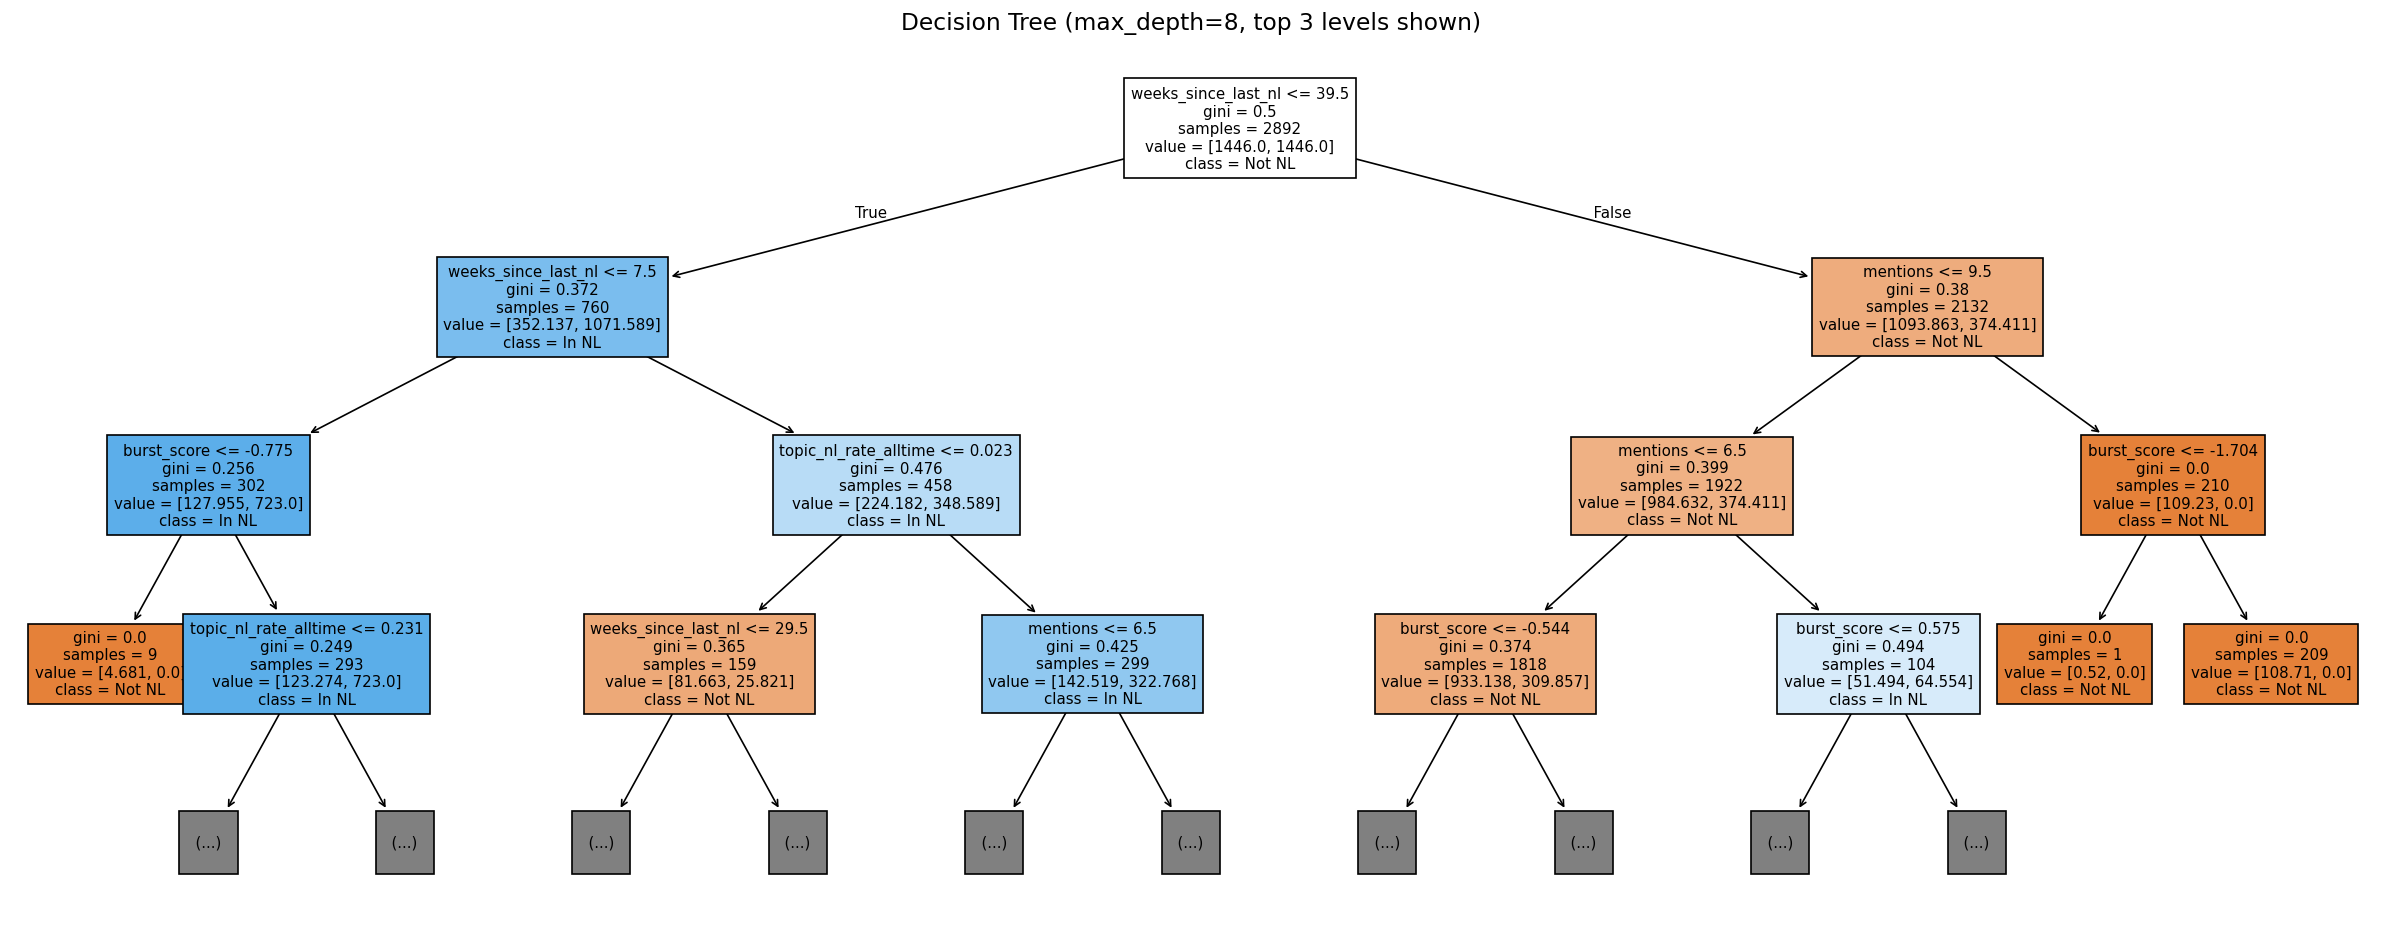

In [38]:
#visualize the tree—explainability is a key advantage over the other two models
fig, ax = plt.subplots(figsize=(20, 8))
plot_tree(
    dt_best,
    feature_names=FEATURE_COLS,
    class_names=["Not NL", "In NL"],
    filled=True,
    max_depth=3, #only show top 3 levels so it's readable
    ax=ax,
    fontsize=9,
)
ax.set_title(f"Decision Tree (max_depth={best_depth}, top 3 levels shown)")
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "model1_decision_tree.png"), dpi=150, bbox_inches='tight')
plt.show()

## 5. Model 2—Logistic Regression

From class: sigmoid function maps linear output to 0-1 probability, weights
found via gradient descent. We use L2 (Ridge) regularization because the slides
cover it as helping with multicollinearity—relevant since topic_nl_rate_8wk
and topic_nl_rate_alltime are correlated (seen in EDA 6 heatmap).
LR is sensitive to scale so we use StandardScaler (fitted on train only).
We tune C (inverse regularization strength) on the validation set.

In [39]:
print("Logistic Regression: tuning C on validation set")
best_C = 0.1
best_val_f1_lr = 0.0

for C in [0.01, 0.05, 0.1, 0.5, 1.0, 5.0]:
    lr = LogisticRegression(
        C=C,
        class_weight='balanced',
        max_iter=1000,
        random_state=42,
    )
    lr.fit(X_train_sc, y_train)
    val_pred = lr.predict(X_val_sc)
    val_f1 = f1_score(y_val, val_pred)
    print(f"  C={C:<6} val F1={val_f1:.4f}")
    if val_f1 > best_val_f1_lr:
        best_val_f1_lr = val_f1
        best_C = C

print(f"\nBest C: {best_C} (val F1={best_val_f1_lr:.4f})")

lr_best = LogisticRegression(
    C=best_C,
    class_weight='balanced',
    max_iter=1000,
    random_state=42,
)
lr_best.fit(X_train_sc, y_train)
lr_pred = lr_best.predict(X_test_sc)
lr_prob = lr_best.predict_proba(X_test_sc)[:, 1]

Logistic Regression: tuning C on validation set
  C=0.01   val F1=0.1364
  C=0.05   val F1=0.1393
  C=0.1    val F1=0.1389
  C=0.5    val F1=0.1389
  C=1.0    val F1=0.1385
  C=5.0    val F1=0.1385

Best C: 0.05 (val F1=0.1393)


In [40]:
print("Model 2: Logistic Regression—Test Set")
print(classification_report(y_test, lr_pred, target_names=["Not in NL", "In NL"]))
print(f"ROC-AUC: {roc_auc_score(y_test, lr_prob):.4f}")
print(f"Avg Precision (AUPRC): {average_precision_score(y_test, lr_prob):.4f}")

#coefficients show what LR actually learned—positive pushes toward newsletter prediction
coef_df = pd.DataFrame({
    "feature": FEATURE_COLS,
    "coefficient": lr_best.coef_[0],
}).sort_values("coefficient", ascending=False)
print("\nCoefficients (scaled features):")
print(coef_df.to_string(index=False))

Model 2: Logistic Regression—Test Set
              precision    recall  f1-score   support

   Not in NL       0.99      0.56      0.71      1051
       In NL       0.08      0.91      0.15        47

    accuracy                           0.57      1098
   macro avg       0.54      0.74      0.43      1098
weighted avg       0.95      0.57      0.69      1098

ROC-AUC: 0.8346
Avg Precision (AUPRC): 0.1456

Coefficients (scaled features):
              feature  coefficient
    topic_nl_rate_8wk     0.254725
topic_nl_rate_alltime     0.141330
          burst_score     0.011374
       is_novel_topic     0.000000
        past_nl_count     0.000000
             mentions    -0.119855
  weeks_since_last_nl    -0.694826


## 6. Model 3—Random Forest (Primary Model)

From class: RF uses bagging—draws bootstrap samples, builds a tree on each,
takes majority vote. At each split randomly selects d candidate features.
The slides say it's "one of the most popular and accurate classifiers for big data."
Parallelizable (n_jobs=-1). We tune n_estimators and max_depth on validation.

In [41]:
print("Random Forest: tuning on validation set")
best_rf = None
best_val_f1_rf = 0.0
best_rf_params = {}

for n_est in [100, 200, 300]:
    for depth in [4, 6, 8]:
        rf = RandomForestClassifier(
            n_estimators=n_est,
            max_depth=depth,
            class_weight='balanced',
            random_state=42,
            n_jobs=-1, #RF is parallelizable—noted in slides as an advantage
        )
        rf.fit(X_train, y_train)
        val_pred = rf.predict(X_val)
        val_f1 = f1_score(y_val, val_pred)
        print(f"  n_est={n_est} depth={depth} val F1={val_f1:.4f}")
        if val_f1 > best_val_f1_rf:
            best_val_f1_rf = val_f1
            best_rf = rf
            best_rf_params = {"n_estimators": n_est, "max_depth": depth}

print(f"\nBest RF: {best_rf_params} (val F1={best_val_f1_rf:.4f})")

rf_pred = best_rf.predict(X_test)
rf_prob = best_rf.predict_proba(X_test)[:, 1]

Random Forest: tuning on validation set
  n_est=100 depth=4 val F1=0.1875
  n_est=100 depth=6 val F1=0.2162
  n_est=100 depth=8 val F1=0.2708
  n_est=200 depth=4 val F1=0.1925
  n_est=200 depth=6 val F1=0.2302
  n_est=200 depth=8 val F1=0.2637
  n_est=300 depth=4 val F1=0.1915
  n_est=300 depth=6 val F1=0.2270
  n_est=300 depth=8 val F1=0.2637

Best RF: {'n_estimators': 100, 'max_depth': 8} (val F1=0.2708)


In [42]:
print("Model 3: Random Forest—Test Set")
print(classification_report(y_test, rf_pred, target_names=["Not in NL", "In NL"]))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_prob):.4f}")
print(f"Avg Precision (AUPRC): {average_precision_score(y_test, rf_prob):.4f}")

rf_importance = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": best_rf.feature_importances_,
}).sort_values("importance", ascending=False)
print("\nFeature importance (mean Gini decrease across all trees):")
print(rf_importance.to_string(index=False))

Model 3: Random Forest—Test Set
              precision    recall  f1-score   support

   Not in NL       0.97      0.93      0.95      1051
       In NL       0.15      0.30      0.20        47

    accuracy                           0.90      1098
   macro avg       0.56      0.61      0.57      1098
weighted avg       0.93      0.90      0.91      1098

ROC-AUC: 0.6975
Avg Precision (AUPRC): 0.1595

Feature importance (mean Gini decrease across all trees):
              feature  importance
  weeks_since_last_nl    0.323093
topic_nl_rate_alltime    0.225756
          burst_score    0.215308
    topic_nl_rate_8wk    0.124840
             mentions    0.111003
       is_novel_topic    0.000000
        past_nl_count    0.000000


## 7. ROC Curves and Confusion Matrices

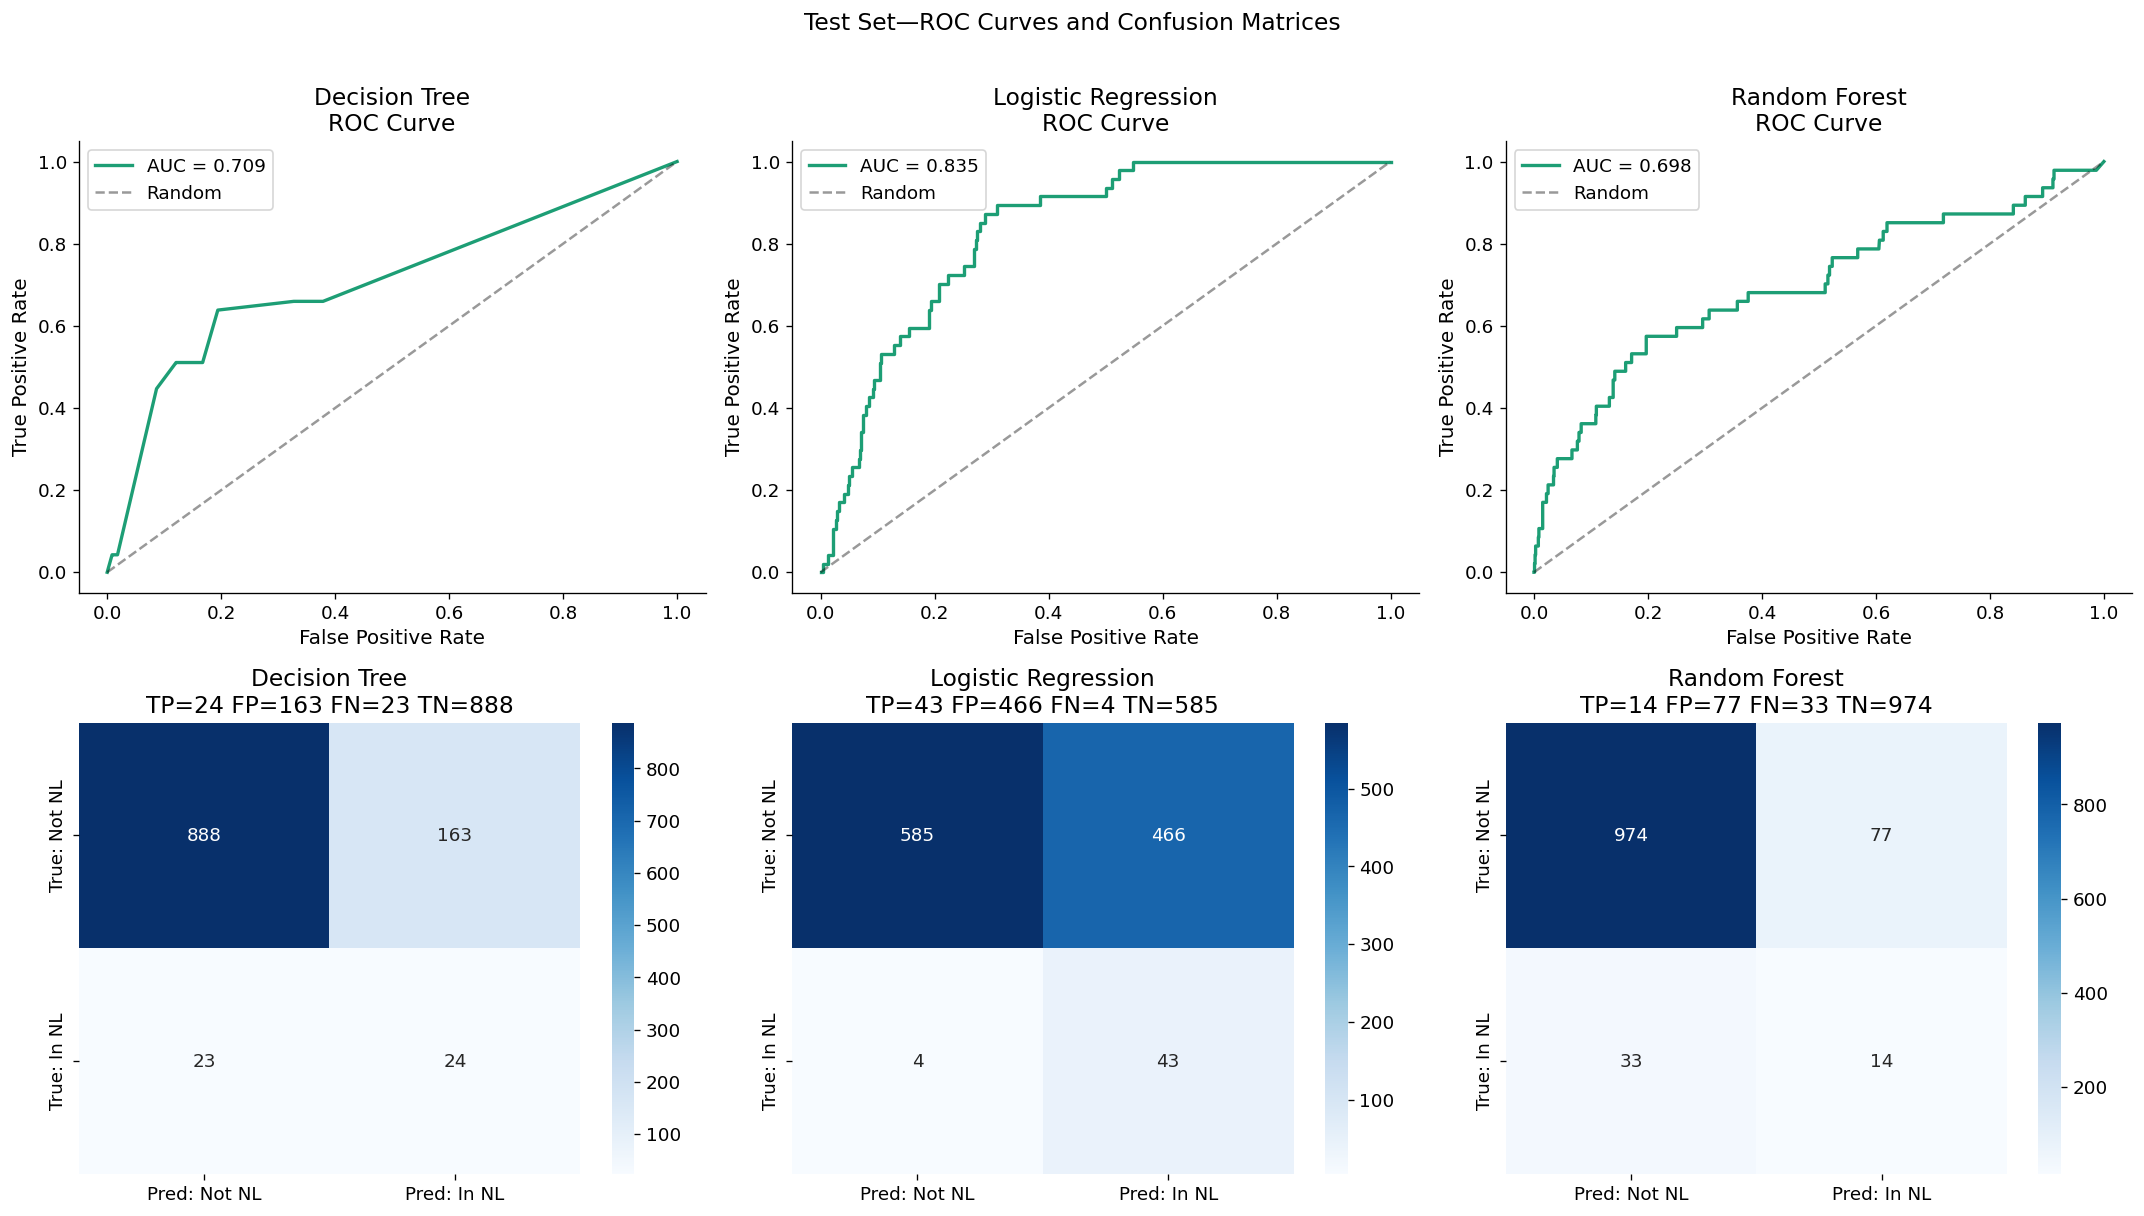

In [43]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

models_eval = [
    ("Decision Tree", dt_prob, dt_pred),
    ("Logistic Regression", lr_prob, lr_pred),
    ("Random Forest", rf_prob, rf_pred),
]

for col, (name, prob, pred) in enumerate(models_eval):
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    axes[0, col].plot(fpr, tpr, color='#1D9E75', linewidth=2, label=f'AUC = {auc:.3f}')
    axes[0, col].plot([0, 1], [0, 1], 'k--', alpha=0.4, label='Random')
    axes[0, col].set_xlabel("False Positive Rate")
    axes[0, col].set_ylabel("True Positive Rate")
    axes[0, col].set_title(f"{name}\nROC Curve")
    axes[0, col].legend()

    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1, col],
                xticklabels=["Pred: Not NL", "Pred: In NL"],
                yticklabels=["True: Not NL", "True: In NL"])
    tn, fp, fn, tp = cm.ravel()
    #FP = hype editors didn't pick up, FN = real signals we missed
    axes[1, col].set_title(f"{name}\nTP={tp} FP={fp} FN={fn} TN={tn}")

plt.suptitle("Test Set—ROC Curves and Confusion Matrices", fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "model_roc_confusion.png"), dpi=150, bbox_inches='tight')
plt.show()

## 8. Feature Importance Across Models

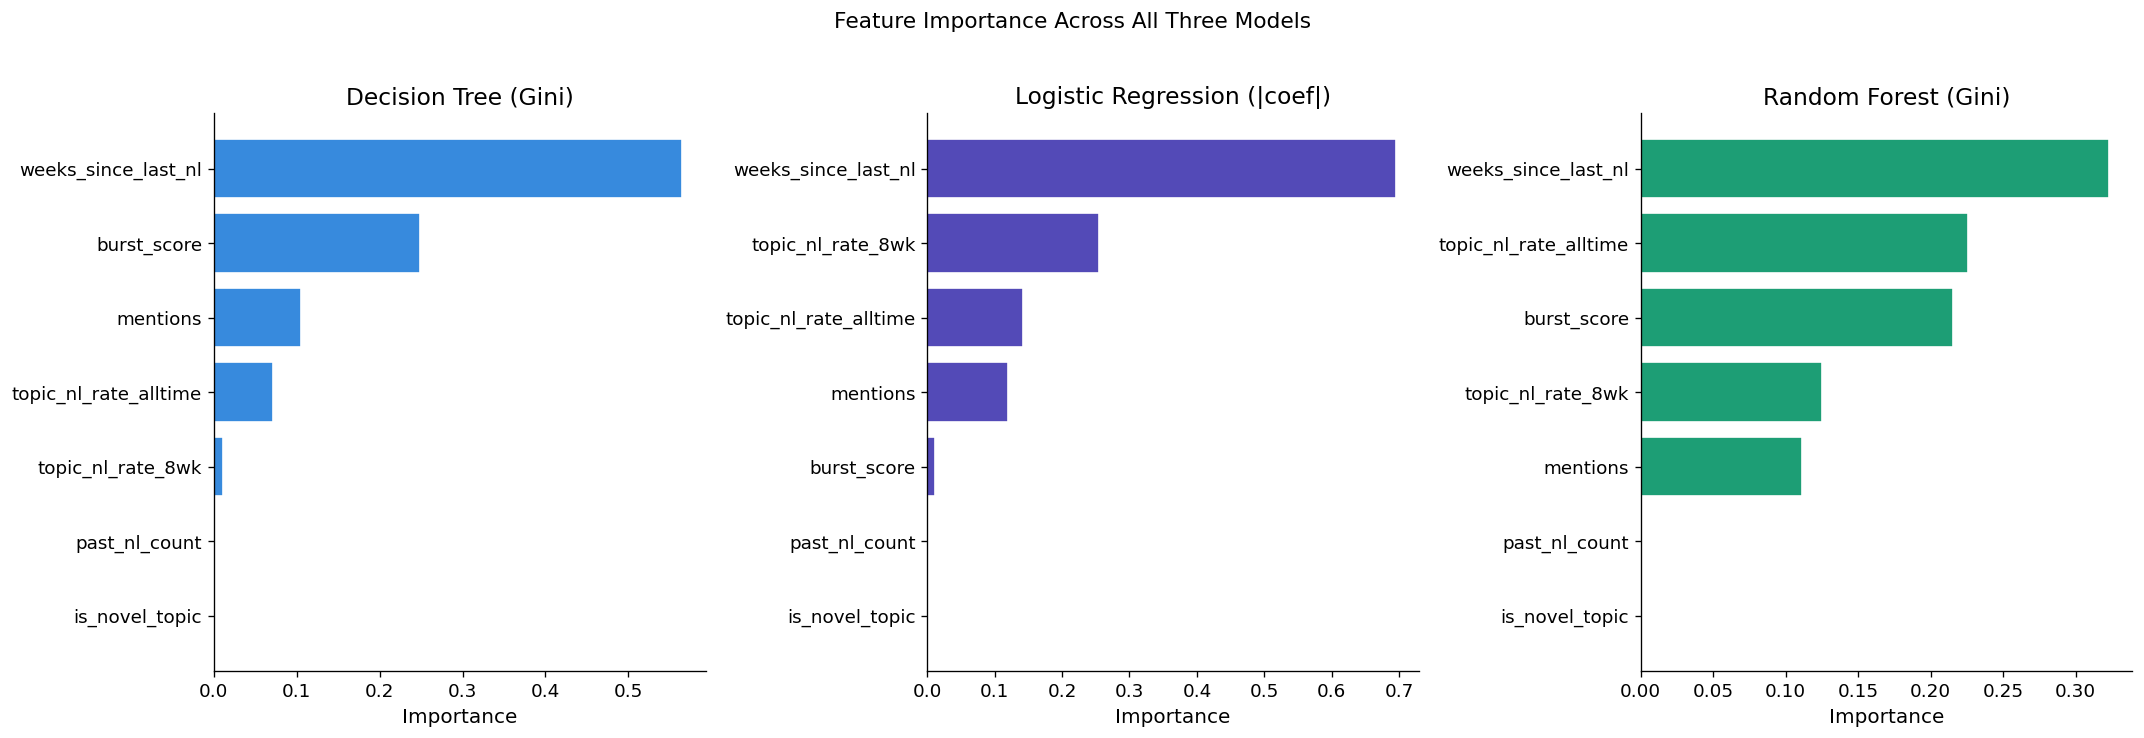

In [44]:
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

dt_imp = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": dt_best.feature_importances_,
}).sort_values("importance", ascending=True)

lr_coef = pd.DataFrame({
    "feature": FEATURE_COLS,
    "importance": np.abs(lr_best.coef_[0]),
}).sort_values("importance", ascending=True)

rf_imp = rf_importance.sort_values("importance", ascending=True)

for ax, (name, imp_df, color) in zip(axes, [
    ("Decision Tree (Gini)", dt_imp, '#378ADD'),
    ("Logistic Regression (|coef|)", lr_coef, '#534AB7'),
    ("Random Forest (Gini)", rf_imp, '#1D9E75'),
]):
    ax.barh(imp_df["feature"], imp_df["importance"], color=color, edgecolor='white')
    ax.set_title(name)
    ax.set_xlabel("Importance")

plt.suptitle("Feature Importance Across All Three Models", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "feature_importance.png"), dpi=150, bbox_inches='tight')
plt.show()

## 9. Precision@K and Recall@K

More useful than binary metrics for our actual use case. Each week we rank all
active topics by predicted probability. P@K = how many of the top K were correct.
R@K = how many of the actual newsletter topics we caught in top K.

In [45]:
def precision_at_k(y_true_week, y_prob_week, k):
    if len(y_prob_week) < k:
        return None
    top_k = np.argsort(y_prob_week)[::-1][:k]
    return y_true_week[top_k].mean()

def recall_at_k(y_true_week, y_prob_week, k):
    if y_true_week.sum() == 0:
        return None
    top_k = np.argsort(y_prob_week)[::-1][:k]
    return y_true_week[top_k].sum() / y_true_week.sum()

test_pd = test_df.to_pandas()
test_weeks = sorted(test_pd["week"].unique().tolist())

print("Precision@K and Recall@K (test set, averaged over weeks with positives)\n")
print(f"{'Model':<25} {'P@3':>7} {'P@5':>7} {'P@10':>7} {'R@3':>7} {'R@5':>7} {'R@10':>7}")
print("-" * 65)

for name, prob in [
    ("Decision Tree", dt_prob),
    ("Logistic Regression", lr_prob),
    ("Random Forest", rf_prob),
]:
    pk3, pk5, pk10, rk3, rk5, rk10 = [], [], [], [], [], []
    for week in test_weeks:
        mask = test_pd["week"].values == week
        week_true = y_test[mask]
        week_prob = prob[mask]
        if week_true.sum() == 0:
            continue
        for k, pl_, rl_ in [(3, pk3, rk3), (5, pk5, rk5), (10, pk10, rk10)]:
            pv = precision_at_k(week_true, week_prob, k)
            rv = recall_at_k(week_true, week_prob, k)
            if pv is not None: pl_.append(pv)
            if rv is not None: rl_.append(rv)
    p3 = np.mean(pk3) if pk3 else 0
    p5 = np.mean(pk5) if pk5 else 0
    p10 = np.mean(pk10) if pk10 else 0
    r3 = np.mean(rk3) if rk3 else 0
    r5 = np.mean(rk5) if rk5 else 0
    r10 = np.mean(rk10) if rk10 else 0
    print(f"{name:<25} {p3:>7.3f} {p5:>7.3f} {p10:>7.3f} {r3:>7.3f} {r5:>7.3f} {r10:>7.3f}")

print(f"\nRandom baseline: ~{y_test.mean():.3f}")

Precision@K and Recall@K (test set, averaged over weeks with positives)

Model                         P@3     P@5    P@10     R@3     R@5    R@10
-----------------------------------------------------------------
Decision Tree               0.197   0.164   0.123   0.288   0.358   0.555
Logistic Regression         0.212   0.191   0.145   0.258   0.407   0.677
Random Forest               0.242   0.155   0.118   0.335   0.358   0.477

Random baseline: ~0.043


## 10. Lead-Time Metric

Our core value proposition is detecting topics BEFORE editors cover them.
Lead time = how many weeks before the actual newsletter appearance did we
first predict this topic above the threshold?

In [46]:
#corrected lead time cell
#as treating week of labeled row as the newsletter week, but the label means
#"newsletter in next 2 weeks" so the actual NL week is week+1 or week+2, not week itslf
PRED_THRESHOLD = 0.3
test_pd["rf_prob"] = rf_prob
lead_times = []

#use nl_week_set built from the actual newsletter data — not from the labels
#filter to test period only
test_week_set = set(test_pd["week"].unique())
nl_in_test = [(t, w) for (t, w) in nl_week_set if w in test_week_set]

for topic, nl_week in nl_in_test:
    nl_date = parse_week(nl_week)
    if nl_date is None:
        continue
    candidates = test_pd[
        (test_pd["canonical_topic"] == topic) &
        (test_pd["week"] < nl_week) &
        (test_pd["rf_prob"] >= PRED_THRESHOLD)
    ].sort_values("week")
    if len(candidates) == 0:
        continue
    first_pred_date = parse_week(candidates.iloc[0]["week"])
    if first_pred_date is None:
        continue
    lead = (nl_date - first_pred_date).days // 7
    if lead>0:
        lead_times.append(lead)

if lead_times:
    print(f"Topics detected early: {len(lead_times)}")
    print(f"Mean lead time: {np.mean(lead_times):.1f} weeks")
    print(f"Median lead time: {np.median(lead_times):.1f} weeks")
    print(f"Max lead time: {np.max(lead_times)} weeks")
else:
    print("No topics detected early in test period.")

Topics detected early: 31
Mean lead time: 9.0 weeks
Median lead time: 9.0 weeks
Max lead time: 20 weeks


## 11. Calibration Curves

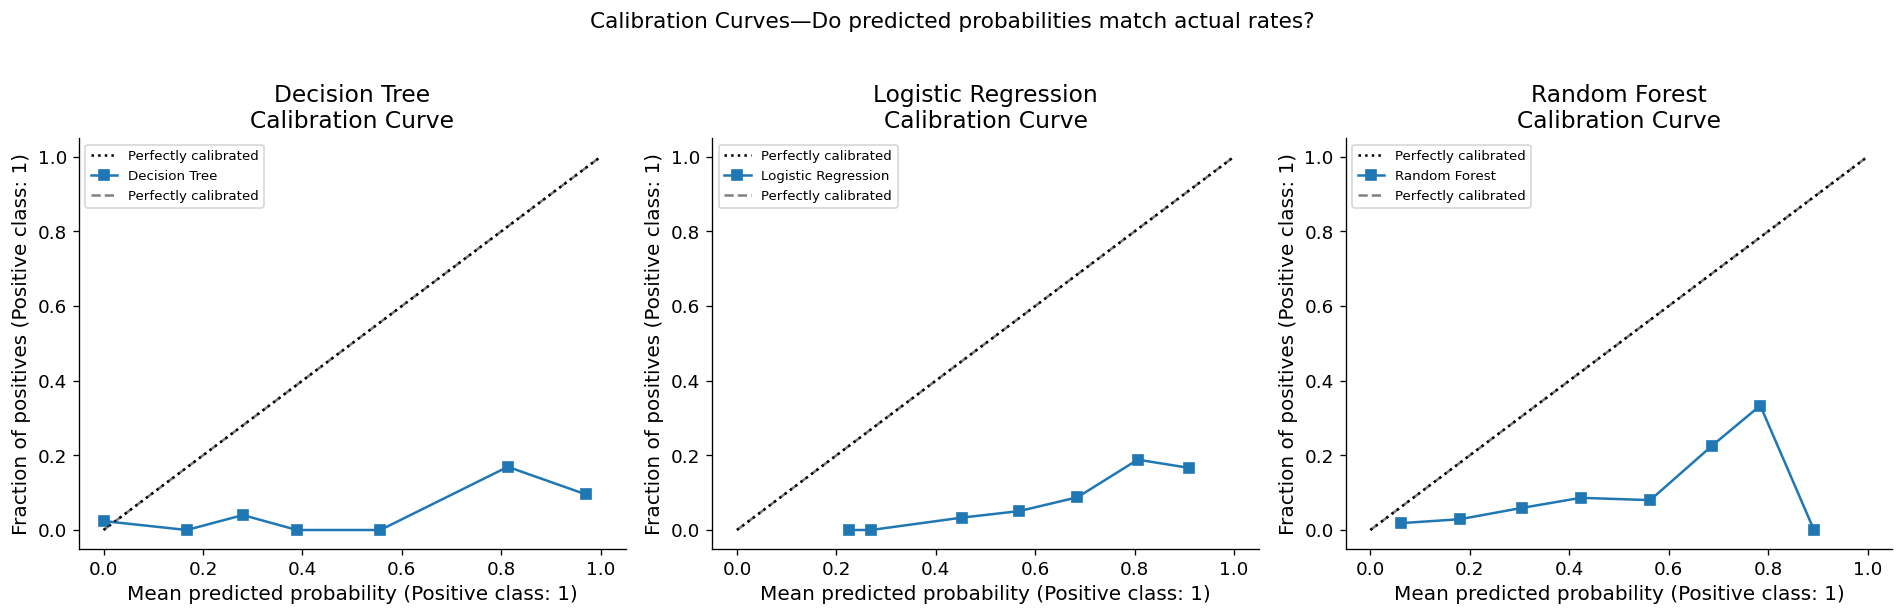

In [47]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, prob) in zip(axes, [
    ("Decision Tree", dt_prob),
    ("Logistic Regression", lr_prob),
    ("Random Forest", rf_prob),
]):
    CalibrationDisplay.from_predictions(y_test, prob, n_bins=8, ax=ax, name=name)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Perfectly calibrated')
    ax.set_title(f"{name}\nCalibration Curve")
    ax.legend(fontsize=8)

plt.suptitle("Calibration Curves—Do predicted probabilities match actual rates?", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(PROCESSED_DIR, "calibration_curves.png"), dpi=150, bbox_inches='tight')
plt.show()

## 12. Core Thesis Test—Does Burst Score Matter for Novel Topics?

Our hypothesis: signal burstiness predicts coverage specifically for topics
editors haven't covered before. We split the test set on is_novel_topic and check.

In [48]:
print("Random Forest: novel vs. established topics\n")
for label, mask_val in [
    ("Novel topics (never in NL before)", 1),
    ("Established topics (covered before)", 0),
]:
    mask = test_pd["is_novel_topic"].values == mask_val
    y_sub = y_test[mask]
    p_sub = rf_prob[mask]
    if y_sub.sum() == 0:
        print(f"{label}: no positives in test set\n")
        continue
    auc = roc_auc_score(y_sub, p_sub) if len(np.unique(y_sub)) > 1 else float('nan')
    ap = average_precision_score(y_sub, p_sub)
    print(f"{label}")
    print(f"  n={mask.sum()} | positives={y_sub.sum()} ({y_sub.mean()*100:.1f}%)")
    print(f"  ROC-AUC={auc:.4f} | AUPRC={ap:.4f}")
    burst_sub = test_pd.loc[mask, "burst_score"].values
    r, p = stats.pointbiserialr(burst_sub, y_sub)
    print(f"  Burst score correlation with label: r={r:.4f}, p={p:.4f}\n")

Random Forest: novel vs. established topics

Novel topics (never in NL before): no positives in test set

Established topics (covered before)
  n=1098 | positives=47 (4.3%)
  ROC-AUC=0.6975 | AUPRC=0.1595
  Burst score correlation with label: r=0.0471, p=0.1186



## 13. Model Comparison and Conclusions

In [53]:
print("=" * 60)
print("FINAL MODEL COMPARISON—TEST SET")
print("=" * 60)
print(f"\nData: {modeling_df.height} active topic-weeks | {modeling_df['label_next2wk'].sum()} positives")
print(f"Split: 70% train / 15% val (tuning) / 15% test (final eval)")
print(f"Class imbalance: class_weight='balanced'—{class_weights[1]:.0f}x positive weighting")

print(f"\n{'Model':<25} {'ROC-AUC':>10} {'AUPRC':>10} {'F1':>8}")
print("-" * 55)
for name, prob, pred in [
    ("Decision Tree", dt_prob, dt_pred),
    ("Logistic Regression", lr_prob, lr_pred),
    ("Random Forest", rf_prob, rf_pred),
]:
    auc = roc_auc_score(y_test, prob)
    ap = average_precision_score(y_test, prob)
    f1 = f1_score(y_test, pred)
    print(f"{name:<25} {auc:>10.4f} {ap:>10.4f} {f1:>8.4f}")


FINAL MODEL COMPARISON—TEST SET

Data: 4678 active topic-weeks | 188 positives
Split: 70% train / 15% val (tuning) / 15% test (final eval)
Class imbalance: class_weight='balanced'—13x positive weighting

Model                        ROC-AUC      AUPRC       F1
-------------------------------------------------------
Decision Tree                 0.7087     0.1264   0.2051
Logistic Regression           0.8346     0.1456   0.1547
Random Forest                 0.6975     0.1595   0.2029


In [ ]:
#save feature matrix and splits to match planned directory structure
splits_dir = os.path.join(os.path.dirname(PROCESSED_DIR), "splits")
os.makedirs(splits_dir, exist_ok=True)

modeling_df.write_csv(os.path.join(PROCESSED_DIR, "topic_week_features.csv"))
train_df.write_csv(os.path.join(splits_dir, "train.csv"))
val_df.write_csv(os.path.join(splits_dir, "val.csv"))
test_df.write_csv(os.path.join(splits_dir, "test.csv"))

print("Saved:")
print(f"{PROCESSED_DIR}/topic_week_features.csv")
print(f"{splits_dir}/train.csv")
print(f"{splits_dir}/val.csv")
print(f"{splits_dir}/test.csv")

Saved:
  /Users/sarinafernandez-grinshpun/CIS2450FinalProject/data/processed/topic_week_features.csv
  /Users/sarinafernandez-grinshpun/CIS2450FinalProject/data/splits/train.csv
  /Users/sarinafernandez-grinshpun/CIS2450FinalProject/data/splits/val.csv
  /Users/sarinafernandez-grinshpun/CIS2450FinalProject/data/splits/test.csv
